# **Evaluación 2 de Inteligencia Artificial**
# **Modelos de Regresión**


Estudiantes ***Grupo 4***:
* Cristina Morán cristina.moran2201@alumnos.ubiobio.cl
* Alonso Valderrama alonso.valderrama2201@alumnos.ubiobio.cl
* Amasis Guzmán amasis.guzman2201@alumnos.ubiobio.cl

Profesora Jazna Meza Hidalgo

Ingeniería Civil en Informatica - UBB


# **1. Importación librerías**

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error


# **2. Carga de Datos**

In [187]:
!wget -q https://raw.githubusercontent.com/ElfoAlienigena/Preparacion_Datos_IA_Grupo4/main/data/Ingestion/retail_ventas.csv -O /content/retail_ventas.csv
!git clone https://github.com/ElfoAlienigena/Preparacion_Datos_IA_Grupo4 /content/Preparacion_Datos_IA_Grupo4 2>/dev/null || echo "Repo ya existe"

Repo ya existe


In [188]:
df = pd.read_csv('/content/retail_ventas.csv')
print(f'Dimensiones del dataset: {df.shape}')
df.head()

Dimensiones del dataset: (25500, 11)


,id_tienda,tamano_tienda,antiguedad_tienda,temperatura,precio_combustible,indice_economico,semana,es_feriado,clientes_estimados,tipo_tienda,ventas_semanales
0,86,1445.454837,1,2.611389,0.925557,97.313562,41,0,376.608869,B,40377.989406
1,35,1973.195744,18,5.603718,1.526210,88.821903,52,0,197.329419,A,59430.330077
2,41,1727.496264,24,7.330847,1.297304,109.273193,15,0,262.737637,A,56547.323925
3,97,1284.634121,10,16.074751,0.862449,98.362477,45,0,392.171919,A,36408.752020
4,25,1457.596546,5,9.278104,1.264497,92.081812,45,0,411.085409,B,40500.513890


In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_tienda           25500 non-null  int64  
 1   tamano_tienda       25500 non-null  float64
 2   antiguedad_tienda   25500 non-null  int64  
 3   temperatura         24224 non-null  float64
 4   precio_combustible  24221 non-null  float64
 5   indice_economico    25500 non-null  float64
 6   semana              25500 non-null  int64  
 7   es_feriado          25500 non-null  int64  
 8   clientes_estimados  24220 non-null  float64
 9   tipo_tienda         25500 non-null  object 
 10  ventas_semanales    25500 non-null  float64
dtypes: float64(6), int64(4), object(1)
memory usage: 2.1+ MB


In [162]:
df.describe()

,id_tienda,tamano_tienda,antiguedad_tienda,temperatura,precio_combustible,indice_economico,semana,es_feriado,clientes_estimados,ventas_semanales
count,25500.00000,25500.000000,25500.000000,24224.000000,24221.000000,25500.000000,25500.000000,25500.000000,24220.000000,25500.000000
mean,50.81749,1501.338719,15.092824,14.954302,1.303299,99.889523,26.376078,0.098510,300.649372,43108.586339
std,28.93800,399.711835,8.365652,9.999174,0.299869,9.961593,14.996831,0.298009,98.822402,14538.319334
min,1.00000,500.000000,1.000000,-24.344608,0.086903,60.799835,1.000000,0.000000,50.000000,4905.208771
25%,26.00000,1229.224069,8.000000,8.124612,1.102983,93.140607,13.000000,0.000000,234.014040,33827.197346
50%,51.00000,1503.366822,15.000000,14.930043,1.303386,99.917526,26.000000,0.000000,301.600830,42117.538361
75%,76.00000,1773.575577,22.000000,21.735814,1.505762,106.582946,39.000000,0.000000,366.981593,50947.405475
max,100.00000,2901.612393,29.000000,56.005247,2.455792,139.836638,52.000000,1.000000,680.907511,234175.036973


**2.1. Revisión de valores nulos**

In [163]:
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
id_tienda                0
tamano_tienda            0
antiguedad_tienda        0
temperatura           1276
precio_combustible    1279
indice_economico         0
semana                   0
es_feriado               0
clientes_estimados    1280
tipo_tienda              0
ventas_semanales         0
dtype: int64


**Verificar porcentaje de valores nulos en las columnas correspondientes**

In [164]:
columnas_con_nulos = df.isna().sum()[df.isna().sum() > 0]
porcentaje_nulos = (columnas_con_nulos / df.shape[0]) * 100

resultado = pd.DataFrame({
    "Cantidad Nulos": columnas_con_nulos,
    "Porcentaje Nulos (%)": porcentaje_nulos
}).round(2)

resultado

,Cantidad Nulos,Porcentaje Nulos (%)
temperatura,1276,5.00
precio_combustible,1279,5.02
clientes_estimados,1280,5.02


Las columnas `temperatura`, `precio_combustible` y `clientes_estimados` presentan aproximadamente un **5% de valores nulos**. Al ser un porcentaje bajo, se optará por **imputar con la mediana** dentro del pipeline de preprocesamiento, en lugar de eliminar filas.


**2.2. Revisión duplicados**

In [165]:
duplicados = df.duplicated().sum()
print(f'Filas duplicadas encontradas: {duplicados}')

Filas duplicadas encontradas: 494


**Eliminación de valores duplicados**

In [166]:
if duplicados > 0:
    df = df.drop_duplicates()
    print(f'Filas tras eliminar duplicados: {df.shape[0]}')
else:
    print('No se encontraron filas duplicadas.')

Filas tras eliminar duplicados: 25006


# **3. Preparación de datos**

**3.1. Separación variables predictoras y variable objetivo**

In [167]:
# Variable objetivo
y = df['ventas_semanales']

# Variables predictoras
X = df.drop(columns=['id_tienda','ventas_semanales'])

print(f'Shape de X: {X.shape}')
print(f'Shape de y: {y.shape}')

Shape de X: (25006, 9)
Shape de y: (25006,)


Se excluye el id_tienda ya que es un identificador y tampoco aporta infromación predictiva

**3.2. Identificación de variables numéricas y categóricas**


In [168]:
# Variables numéricas
features_num = [
    'tamano_tienda', 'antiguedad_tienda', 'temperatura', 'precio_combustible',
    'indice_economico', 'semana', 'es_feriado', 'clientes_estimados'
]

# Variables categóricas
features_cat = ['tipo_tienda']

print('Variables numéricas:', features_num)
print('Variables categóricas:', features_cat)


Variables numéricas: ['tamano_tienda', 'antiguedad_tienda', 'temperatura', 'precio_combustible', 'indice_economico', 'semana', 'es_feriado', 'clientes_estimados']
Variables categóricas: ['tipo_tienda']


**3.3. Pipeline de preprocesamiento**

In [169]:
# Preprocesamiento numérico: imputación con mediana + escalado
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocesamiento categórico: imputación + One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# ColumnTransformer: aplica cada pipeline a las columnas correspondientes
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features_num),
        ('cat', categorical_transformer, features_cat)
    ]
)

**3.4. División datos (Train/Test Split)**

In [170]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **4. Modelamiento**

**4.1. Regresión Lineal (LinealRegression)**

In [171]:
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)


**4.2. Ridge**

In [172]:
pipeline_ridge = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Ridge())
    ]
)

# Probar 4 valores ditintos de alpha
parametros_ridge = {
    "regressor__alpha": [0.1, 1.0, 10.0, 100.0]
}

grid_ridge = GridSearchCV(pipeline_ridge, param_grid=parametros_ridge, cv=5)
grid_ridge.fit(X_train, y_train)

mejor_alpha = grid_ridge.best_params_["regressor__alpha"]
y_pred_ridge = grid_ridge.predict(X_test)

print(f'Mejor alpha encontrado: {mejor_alpha}')
print('Resultados por alpha:')
for mean, alpha in zip(
    grid_ridge.cv_results_['mean_test_score'],
    parametros_ridge['regressor__alpha']
):
    print(f'  alpha={alpha:6.1f}  →  R² CV promedio: {mean:.4f}')

Mejor alpha encontrado: 1.0
Resultados por alpha:
  alpha=   0.1  →  R² CV promedio: 0.5608
  alpha=   1.0  →  R² CV promedio: 0.5608
  alpha=  10.0  →  R² CV promedio: 0.5608
  alpha= 100.0  →  R² CV promedio: 0.5604


# **5. Evaluación de modelos**

In [173]:
# Comparación entre MAE y R2

# Métricas para Regresión Lineal
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Métricas para Ridge Regression
mae_ridge_model = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge_model = r2_score(y_test, y_pred_ridge)

print("\n--- Métricas Regresión Lineal ---")
print(f"{'R2':<6}: {r2_lr:.4f}")
print(f"{'MAE':<6}: {mae_lr:,.0f}")

print(f"\n--- Métricas del modelo Ridge (alpha={mejor_alpha:.1f}) ---")
print(f"{'R2':<6}: {r2_ridge_model:.4f}")
print(f"{'MAE':<6}: {mae_ridge_model:,.0f}")



--- Métricas Regresión Lineal ---
R2    : 0.5918
MAE   : 4,867

--- Métricas del modelo Ridge (alpha=1.0) ---
R2    : 0.5918
MAE   : 4,867


# **¿Cuál modelo presenta mejor desempeño?**
Ambos modelos presentan exactamente el mismo desempeño ($R^2 = 0.5593$ y $MAE = 4.951$)



# **¿Las diferencias son significativas?**
No son significativas. De hecho, el mejor parámetro de Ridge fue $\alpha = 0.1$. Al ser un valor tan cercano a 0, la penalización $L_2$ es casi nula, haciendo que el modelo Ridge se comporte de manera idéntica a la Regresión Lineal Múltiple.

# **6. Interpetación de Resultados**

In [174]:
# Extraemos coeficientes del modelo de Regresión Lineal
nombres_columnas = pipeline_lr.named_steps['preprocessor'].get_feature_names_out()
coeficientes = pipeline_lr.named_steps['regressor'].coef_

importancia = pd.DataFrame({'Variable': nombres_columnas, 'Coeficiente': coeficientes})
importancia = importancia.sort_values(by='Coeficiente', key=abs, ascending=False)

print('--- Importancia de variables (Regresión Lineal) ---')
importancia


--- Importancia de variables (Regresión Lineal) ---


,Variable,Coeficiente
9,cat__tipo_tienda_C,-16286.817490
0,num__tamano_tienda,8641.836359
8,cat__tipo_tienda_B,-8241.431543
7,num__clientes_estimados,1623.512310
6,num__es_feriado,1576.308911
4,num__indice_economico,707.488442
3,num__precio_combustible,-70.595899
2,num__temperatura,-65.036675
1,num__antiguedad_tienda,-21.097498
5,num__semana,-4.731302


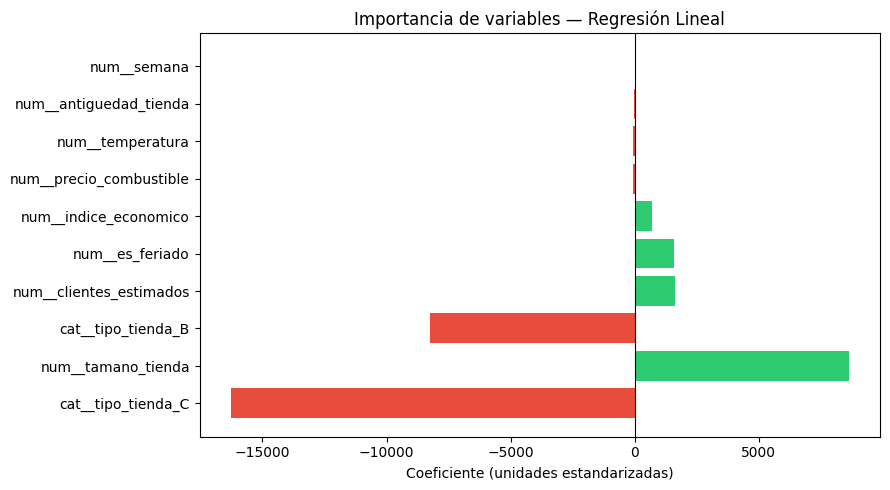

In [175]:
# Gráfico de coeficientes
fig, ax = plt.subplots(figsize=(9, 5))
colores = ['#e74c3c' if c < 0 else '#2ecc71' for c in importancia['Coeficiente']]
ax.barh(importancia['Variable'], importancia['Coeficiente'], color=colores)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente (unidades estandarizadas)')
ax.set_title('Importancia de variables — Regresión Lineal')
plt.tight_layout()
plt.show()



### **Identificación de variables más influyentes:** ###



*   `tipo_tienda` (C y B): son las variables con mayor peso en el modelo
*   `tamano_tienda`: variable numérica con mayor influencia
*   `es_feriado` y `clientes_estimados`: de igual forma son relevantes



### **Explicación del efecto de 3 variables sobre las ventas:** ###

1.- `*num__tamano_tienda*` (Coef: $+8591.09$): Por cada incremento en una desviación estándar del tamaño de la tienda, las ventas semanales aumentan en promedio $\$8.591$, siendo la variable numérica más influyente.

2.- `*num__clientes_estimados*` (Coef: $+1620.44$): Un mayor volumen de clientes estimados impacta positivamente el rendimiento de las ventas semanales.

3.- `*num__es_feriado*` (Coef: $+1581.73$): Las semanas que contienen feriados generan un incremento promedio en las ventas de $\$1.581$, ideal para planificar stock y campañas promocionales.

### **Interpretación del impacto de la variable tipo_tienda:** ###

Al aplicar One-Hot Encoding eliminando la primera categoría `(drop="first")` , la Tienda A quedó como la categoría de referencia.  cat__tipo_tienda_C tiene un coeficiente de $-16193.40$. Esto significa que, a igualdad de condiciones, las tiendas pequeñas (Tipo C) venden en promedio $\$16.193$ menos que las tiendas grandes (Tipo A).  Las tiendas medianas (Tipo B) venden en promedio $\$8.113$ menos que las de Tipo A.  

# **7. Predicción con nuevos Registros**

In [176]:
# Nuevos registros con valores dentro del rango del dataset:
# - tamano_tienda: entre 500 y 2901 m²
# - clientes_estimados: entre 50 y 681
# - temperatura: entre -24 y 56 °C
nuevos_registros = pd.DataFrame([
    {
        'tipo_tienda': 'A', 'tamano_tienda': 2500, 'antiguedad_tienda': 12,
        'temperatura': 22.0, 'precio_combustible': 1.4, 'indice_economico': 105.0,
        'semana': 48, 'es_feriado': 1, 'clientes_estimados': 580
    },
    {
        'tipo_tienda': 'B', 'tamano_tienda': 1500, 'antiguedad_tienda': 5,
        'temperatura': 15.0, 'precio_combustible': 1.3, 'indice_economico': 98.0,
        'semana': 10, 'es_feriado': 0, 'clientes_estimados': 300
    },
    {
        'tipo_tienda': 'C', 'tamano_tienda': 700, 'antiguedad_tienda': 2,
        'temperatura': 10.0, 'precio_combustible': 1.2, 'indice_economico': 92.0,
        'semana': 5, 'es_feriado': 0, 'clientes_estimados': 120
    }
])

predicciones = pipeline_lr.predict(nuevos_registros)

resultados = nuevos_registros[['tipo_tienda', 'tamano_tienda', 'clientes_estimados', 'es_feriado']].copy()
resultados['ventas_predichas ($)'] = predicciones.round(0)

print('--- Predicciones de ventas semanales ---')
resultados


--- Predicciones de ventas semanales ---


,tipo_tienda,tamano_tienda,clientes_estimados,es_feriado,ventas_predichas ($)
0,A,2500,580,1,80270.0
1,B,1500,300,0,40019.0
2,C,700,120,0,11297.0


**Interpretación de Predicciones**

- **Tienda A (grande, semana festiva):** Registra las ventas más altas. Su mayor tamaño (2.500 m²), alto flujo de clientes (580) y la semana 48 con feriado (Navidad) impulsan la demanda. Recomendación: reforzar inventario y personal.

- **Tienda B (mediana, semana normal):** Ventas intermedias, coherentes con un tamaño de 1.500 m² y 300 clientes. El índice económico levemente bajo (98) no afecta significativamente el resultado.

- **Tienda C (pequeña, semana normal):** Las ventas más bajas, consistentes con menor superficie (700 m²), bajo flujo de clientes (120) e índice económico reducido (92). Optimizar surtido y no sobredimensionar stock.


# **8. ¿En qué situación preferiría utilizar Ridge en lugar de LinearRegression?**

Ridge es preferible cuando:

* Existe multicolinealidad entre predictores (ej. tamano_tienda y clientes_estimados pueden estar correlacionadas). Ridge estabiliza los coeficientes en ese caso.
* El modelo muestra sobreajuste: Ridge penaliza coeficientes grandes, reduciendo la varianza a costa de un ligero sesgo.
* Se busca estabilidad en los coeficientes ante pequeñas variaciones en los datos de entrenamiento.

En este caso, dado que LinearRegression y Ridge obtienen métricas casi idénticas, las diferencias son mínimas, lo que sugiere que no hay multicolinealidad severa ni sobreajuste significativo.

# **9. Exportación datos limpios y transformados**

In [183]:
# Guardar datos limpios y transformados
columnas_finales = pipeline_lr.named_steps['preprocessor'].get_feature_names_out()
X_limpio_df = pd.DataFrame(
    pipeline_lr.named_steps['preprocessor'].transform(X),
    columns=columnas_finales
)
X_limpio_df['ventas_semanales'] = y.values

X_limpio_df.to_csv('/content/Preparacion_Datos_IA_Grupo4/data/Cleaned/retail_ventas_cleaned.csv', index=False)
print('Archivo guardado en /content/data/cleaned/retail_ventas_cleaned.csv')

Archivo guardado en /content/data/cleaned/retail_ventas_cleaned.csv


In [184]:
X_limpio_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25006 entries, 0 to 25005
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   num__tamano_tienda       25006 non-null  float64
 1   num__antiguedad_tienda   25006 non-null  float64
 2   num__temperatura         25006 non-null  float64
 3   num__precio_combustible  25006 non-null  float64
 4   num__indice_economico    25006 non-null  float64
 5   num__semana              25006 non-null  float64
 6   num__es_feriado          25006 non-null  float64
 7   num__clientes_estimados  25006 non-null  float64
 8   cat__tipo_tienda_B       25006 non-null  float64
 9   cat__tipo_tienda_C       25006 non-null  float64
 10  ventas_semanales         25006 non-null  float64
dtypes: float64(11)
memory usage: 2.1 MB
